In [52]:
import pandas as pd

# data up to June 30, 2026
df = pd.DataFrame({
    "Region": [
        "Atlantic",
        "Quebec",
        "Northern Ontario",
        "Greater Toronto Area",
        "Southern Ontario",
        "Prairie",
        "Pacific",
        "Not yet assigned to a region",
        "Grand total",
    ],
    "Not yet actionable": [541, 179354, 15153, 63856, 3411, 14093, 32424, 156078, 464910],
    "Removal not possible": [201, 14955, 1791, 8320, 508, 2739, 1634, 2471, 32619],
    "Wanted": [62, 8830, 919, 21219, 363, 975, 1473, 6, 33847],
    "Removal in progress": [163, 14752, 1570, 12660, 298, 2526, 3579, 5279, 40827],
    "Total": [967, 217891, 19433, 106055, 4580, 20333, 39110, 163834, 572203],
})
df

,Region,Not yet actionable,Removal not possible,Wanted,Removal in progress,Total
0,Atlantic,541,201,62,163,967
1,Quebec,179354,14955,8830,14752,217891
2,Northern Ontario,15153,1791,919,1570,19433
3,Greater Toronto Area,63856,8320,21219,12660,106055
4,Southern Ontario,3411,508,363,298,4580
5,Prairie,14093,2739,975,2526,20333
6,Pacific,32424,1634,1473,3579,39110
7,Not yet assigned to a region,156078,2471,6,5279,163834
8,Grand total,464910,32619,33847,40827,572203


In [53]:
df_non_total = df[~df["Region"].isin(["Grand total"])]
df_non_total

,Region,Not yet actionable,Removal not possible,Wanted,Removal in progress,Total
0,Atlantic,541,201,62,163,967
1,Quebec,179354,14955,8830,14752,217891
2,Northern Ontario,15153,1791,919,1570,19433
3,Greater Toronto Area,63856,8320,21219,12660,106055
4,Southern Ontario,3411,508,363,298,4580
5,Prairie,14093,2739,975,2526,20333
6,Pacific,32424,1634,1473,3579,39110
7,Not yet assigned to a region,156078,2471,6,5279,163834


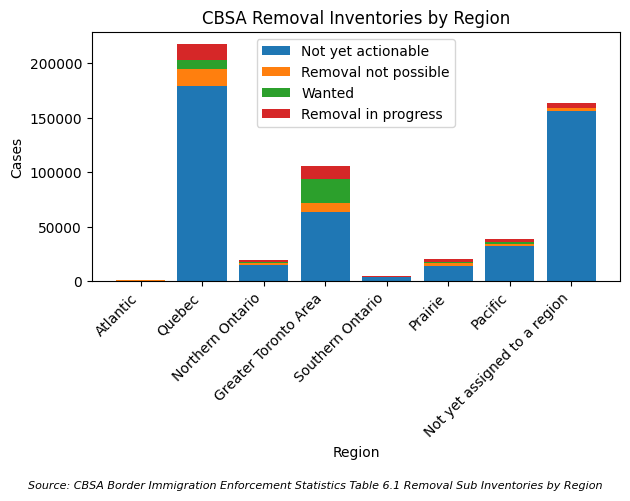

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

df = df_non_total
status_cols = [
    "Not yet actionable",
    "Removal not possible",
    "Wanted",
    "Removal in progress",
]

fig, ax = plt.subplots()
bottom = [0] * len(df)
for col in status_cols:
    ax.bar(df["Region"], df[col], bottom=bottom, label=col)
    bottom = [a + b for a, b in zip(bottom, df[col])]

ax.set_title("CBSA Removal Inventories by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Cases")

ax.legend(
    title=None,
    loc="upper center",
    ncol=1,
    frameon=True
)

plt.figtext(
    0.5, -0.03,
    "Source: CBSA Border Immigration Enforcement Statistics Table 6.1 Removal Sub Inventories by Region",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.subplots_adjust(bottom=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()